# Customer Churn Analysis — Helio Habits



## Project Overview

This project analyzes customer activity, subscriptions, and cancellations for Helio Habits.

The analysis uses Python and Pandas to clean and combine data, explore customer behavior, and identify patterns associated with customer cancellations.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PULL_DATE = pd.Timestamp("2026-03-31")
END_90 = pd.Timestamp("2026-06-29")

answers = {}   # answers["Q1"] = (value, "one line on how we got it")

## Part 1: Clean-Up
### 1.1 Load and count (Q1)
First, we load all the provided data files from README_DATA.txt. Then we count the number of rows 
in the original transactions dataset before making any changes.

In [3]:
import pandas as pd

# Load all data files
tx = pd.read_csv("data_student/transactions.csv", dtype={"customer_id": str})
cust = pd.read_excel("data_student/customers.xlsx", sheet_name="customers")
leg = pd.read_excel("data_student/customers.xlsx", sheet_name="legacy_ids", header=2)
subs = pd.read_csv("data_student/subscriptions.csv")
act = pd.read_csv("data_student/activity_monthly.csv")
fx = pd.read_csv("data_student/fx_rates.csv")

# the final answer table
answers = {}

# Count transaction rows as delivered forQ1
print(f"Number of transaction rows are: {len(tx)}")

answers["Q1"] = (
    len(tx),
    "Counted rows fromtransactions.csv as delivered"
)

Number of transaction rows are: 10818


### Remove duplicate transactions

Convert updated_at to datetime, sort the records, and keep the newest record for each txn_id.


In [4]:
# Convert updated_at to datetime

tx["updated_at"] = pd.to_datetime(
    tx["updated_at"],
    format="mixed",
    utc=True
)

tx = tx.sort_values("updated_at")

tx = tx.drop_duplicates("txn_id", keep="last")

# Count transaction rows after removing repeats for Q2
print(f"Number of rows after removing repeats: {len(tx)}")

answers["Q2"] = (
    len(tx),
    "Removed duplicate txn_id and kept the newest record"
)

Number of rows after removing repeats: 10528


### 1.3 Fix the amounts and missing currency (Q3, Q4)
Some transaction amounts are 100 times too large because they were stored in cents or øre. We identify these amounts and divide them by 100.

For missing currencies, we use the customer's country to determine the local currency. We then convert the corrected amounts to euros using the FX rates.

In [5]:
# Q3

tx_q3 = tx.copy()

# Find the normal minimum amount for each group
normal_amount = (
    tx_q3[tx_q3["currency"].notna()]
    .groupby(["currency", "plan", "billing_cycle"])["amount"]
    .min()
)

# Match each transaction to its group's normal amount
group_key = pd.MultiIndex.from_frame(
    tx_q3[["currency", "plan", "billing_cycle"]]
)

normal_amount_for_row = group_key.map(normal_amount)

# Find amounts that are 100 times the normal amount
wrong_amount = (
    normal_amount_for_row.notna()
    & np.isclose(
        tx_q3["amount"].to_numpy(),
        np.asarray(normal_amount_for_row, dtype=float) * 100
    )
)

# Count changed rows
q3 = wrong_amount.sum()

# Fix the amounts
tx_q3.loc[wrong_amount, "amount"] = (
    tx_q3.loc[wrong_amount, "amount"] / 100
)

print("Number of rows changed =", int(q3))

answers["Q3"] = (
    int(q3),
    "Amounts 100 times the normal amount were divided by 100"
)

Number of rows changed = 1291


In [6]:
# Q4

tx_q4 = tx_q3.copy()

# Get customer country
customer_country = cust[["customer_id", "country"]].copy()

# Clean country names
customer_country["country"] = (
    customer_country["country"]
    .astype(str)
    .str.strip()
    .str.lower()
)

# Add country to transactions
tx_q4 = tx_q4.merge(
    customer_country,
    on="customer_id",
    how="left"
)

# Country to currency
country_currency = {
    "no": "NOK",
    "nor": "NOK",
    "norway": "NOK",
    "se": "SEK",
    "swe": "SEK",
    "sweden": "SEK",
    "dk": "DKK",
    "dnk": "DKK",
    "denmark": "DKK",
    "de": "EUR",
    "deu": "EUR",
    "germany": "EUR",
    "fi": "EUR",
    "fin": "EUR",
    "finland": "EUR"
}

# Find blank currencies
blank_currency = tx_q4["currency"].isna()

# Fill blank currency from country
tx_q4.loc[blank_currency, "currency"] = (
    tx_q4.loc[blank_currency, "country"]
    .map(country_currency)
)

# Print Q4
print("Q4 = Used customer's country to determine local currency,Blank currency was treated as the customer's local currency")
#print("Blank currencies remaining:", int(tx_q4["currency"].isna().sum()))

answers["Q4"] = (
    "Used customer's country to determine local currency",
    "Blank currency was treated as the customer's local currency"
)

Q4 = Used customer's country to determine local currency,Blank currency was treated as the customer's local currency


In [7]:
# Convert all amounts to EUR

tx_q4 = tx_q4.merge(
    fx,
    on="currency",
    how="left"
)

tx_q4["amount_eur"] = (
    tx_q4["amount"] * tx_q4["eur_per_unit"]
)

tx_q4[
    ["customer_id", "amount", "currency", "eur_per_unit", "amount_eur"]
].head(10)

,customer_id,amount,currency,eur_per_unit,amount_eur
0,C101303,39.90,EUR,1.0000,39.900000
1,C100026,2000.00,SEK,0.0895,179.000000
2,C100882,39.90,EUR,1.0000,39.900000
3,C101084,179.00,EUR,1.0000,179.000000
4,C101740,73.88,DKK,0.1340,9.899920
5,C101142,148.51,DKK,0.1340,19.900340
6,C101368,115.12,NOK,0.0860,9.900320
7,C100214,2081.40,NOK,0.0860,179.000400
8,C101391,445.81,SEK,0.0895,39.899995
9,C100116,349.00,EUR,1.0000,349.000000


### 1.4 Tidy the labels and mark impossible values



The customer data has different names for the same country, plan, and acquisition channel. We clean them so that each one has the same name.

We also mark ages that are not realistic, but we do not delete those customers.

**Clean the country names**

In [8]:
# Clean country labels
cust["country"] = (
    cust["country"]
    .astype("string")
    .str.strip()
    .str.lower()
)

country_clean = {
    "no": "Norway",
    "nor": "Norway",
    "norway": "Norway",
    "se": "Sweden",
    "swe": "Sweden",
    "sweden": "Sweden",
    "dk": "Denmark",
    "dnk": "Denmark",
    "denmark": "Denmark",
    "de": "Germany",
    "deu": "Germany",
    "germany": "Germany",
    "deutschland": "Germany",
    "fi": "Finland",
    "fin": "Finland",
    "finland": "Finland"
}

cust["country"] = cust["country"].replace(country_clean)

print(cust["country"].value_counts(dropna=False))

country
Norway     700
Germany    397
Sweden     391
Denmark    334
Finland    218
Name: count, dtype: Int64


**Clean the plan names**

In [9]:
# Clean plan labels
cust["plan_tier"] = (
    cust["plan_tier"]
    .astype("string")
    .str.strip()
    .str.lower()
)

plan_clean = {
    "basic": "basic",
    "plus": "plus",
    "plus+": "plus",
    "pro": "pro",
    "professional": "pro"
}

cust["plan_tier"] = cust["plan_tier"].replace(plan_clean)

print(cust["plan_tier"].value_counts(dropna=False))

plan_tier
basic    1048
plus      656
pro       336
Name: count, dtype: Int64


**Clean the acquisition channel names**

In [10]:
# Clean acquisition channel
cust["acquisition_channel"] = (
    cust["acquisition_channel"]
    .astype("string")
    .str.strip()
    .str.lower()
)

channel_clean = {
    "organic": "organic",
    "paid_social": "paid social",
    "paid social": "paid social",
    "paidsocial": "paid social",
    "referral": "referral",
    "refer-a-friend": "referral",
    "partner": "partner",
    "partnership": "partner"
}

cust["acquisition_channel"] = (
    cust["acquisition_channel"].replace(channel_clean)
)

print(cust["acquisition_channel"].value_counts(dropna=False))

acquisition_channel
organic        735
paid social    547
partner        425
referral       333
Name: count, dtype: Int64


**Mark the invalid ages**

In [11]:
# Mark invalid ages without deleting rows
cust["age_invalid"] = (
    (cust["age"] < 18) |
    (cust["age"] > 100)
)

print("Invalid ages:", cust["age_invalid"].sum())

print(
    cust.loc[
        cust["age_invalid"],
        ["customer_id", "age"]
    ]
)

Invalid ages: 7
     customer_id  age
254      C100356  201
364      C101813  180
571      C100356  201
639      C101645   -3
1034     C101590  999
1852     C100491  140
2016     C100130    0


### 1.5 Email vs Data Dictionary (Q12)
*Which statement did you not follow, and what in the data told you?*

The email says to ignore the currency column and treat all transaction amounts as euros. 
We did not follow this instruction because the data dictionary states that amounts are in 
the customer's own billing currency, and the `fx_rates.csv` file provides exchange rates 
for converting them to euros. Therefore, we used the currency information and converted 
the amounts to EUR using the provided exchange rates. For blank currencies, we used the 
customer's local currency based on their country.

## Part 2: Who Was Subscribed, and Who Left?


### 2.1 Customers subscribed on 31 March 2026(Q5)

We first convert the subscription start and cancellation dates to datetime format. 
A customer is considered subscribed on 31 March 2026 if their subscription started 
on or before 31 March 2026 and they had not cancelled by that date. We then count 
the customers who meet both conditions.

In [12]:
# Convert subscription dates to datetime
subs["sub_start"] = pd.to_datetime(subs["sub_start"])
subs["sub_end"] = pd.to_datetime(subs["sub_end"])

# Find customers subscribed on 31 March 2026
subscribed = ((subs["sub_start"] <= PULL_DATE) & (subs["sub_end"].isna() | (subs["sub_end"] > PULL_DATE)))

# Count subscribed customers
q5 = subscribed.sum()
#q5 = len(subs[subscribed])


print("Customers subscribed on 31 March 2026:", q5)

answers["Q5"] = (
    q5,
    "Started on or before 31 March 2026 and had not cancelled by that date"
)

Customers subscribed on 31 March 2026: 1124


### 2.2 Customers who cancelled between 1 April and 29 June 2026(Q6)

We identify customers who were subscribed on 31 March 2026 and then cancelled 
between 1 April and 29 June 2026. We count these customers and calculate their 
percentage out of all customers who were subscribed on 31 March 2026.

In [13]:
# Find customers who cancelled between 1 April and 29 June 2026
cancelled = (
    subscribed &
    (subs["sub_end"] > PULL_DATE) &
    (subs["sub_end"] <= END_90)
)

# Count cancelled customers
cancelled_count = cancelled.sum()

# Calculate cancellation percentage
q6 = cancelled_count / q5 * 100

print("Customers cancelled:", cancelled_count)
print("Cancellation percentage:", round(q6, 2))

answers["Q6"] = (q6,
    "Percentage of Q5 customers who cancelled between 1 April and 29 June 2026"
)

Customers cancelled: 201
Cancellation percentage: 17.88


### 3.1 Compare customers by acquisition channel

First, we keep only the customers who were subscribed on 31 March 2026.

Then, we add the acquisition channel for each customer and mark whether the customer cancelled between 1 April and 29 June 2026.

Finally, we group the customers by acquisition channel. For each group, we calculate:
- the number of customers,
- the percentage of all subscribed customers in the group, and
- the percentage of customers who cancelled.

This helps us identify which acquisition groups are small enough to call and have a higher cancellation rate.

In [14]:
# Keep customers who were subscribed on 31 March
active = subs[subscribed].copy()

# Add acquisition channel
active = active.merge(
    cust[["customer_id", "acquisition_channel"]],
    on="customer_id"
)

# Mark customers who cancelled
active["cancelled"] = (
    (active["sub_end"] > PULL_DATE) &
    (active["sub_end"] <= END_90)
)

# Count customers in each group
summary = active.groupby("acquisition_channel")["customer_id"].count().to_frame("customers")

# Count cancelled customers
summary["cancelled"] = active.groupby("acquisition_channel")["cancelled"].sum()

# Calculate percentages
summary["size_%"] = summary["customers"] / q5 * 100
summary["cancel_%"] = summary["cancelled"] / summary["customers"] * 100

summary

,customers,cancelled,size_%,cancel_%
acquisition_channel,,,,
organic,486,73,43.238434,15.020576
paid social,354,52,31.494662,14.689266
partner,154,67,13.701068,43.506494
referral,212,33,18.861210,15.566038


### 3.2 Choose the group to call(Q7-Q9)

We first select groups that contain **15% or less** of all customers.
From these smaller groups, we then keep only the groups whose cancellation
percentage is **higher than the overall cancellation percentage**.

The groups that meet both conditions are shown below.

In [15]:
# Find groups that are 15% or less
small = summary[summary["size_%"] <= 15]

# Find groups with cancellation above the average
good = small[small["cancel_%"] > q6]

print(good)

# Select the first qualifying group
group = good.index[0]

# Store Q7, Q8 and Q9
answers["Q7"] = (
    f"acquisition_channel={group}",
    "Selected the qualifying group"
)

answers["Q8"] = (
    round(good.loc[group, "size_%"], 2),
    "Calculated the group size as a percentage of Q5"
)

answers["Q9"] = (
    round(good.loc[group, "cancel_%"], 2),
    "Calculated the group's cancellation percentage"
)

                     customers  cancelled     size_%   cancel_%
acquisition_channel                                            
partner                    154         67  13.701068  43.506494


### Figure 1 — Group size and cancellation rate

This figure compares the size of each customer group with its cancellation rate.
The dashed line shows the **15% limit** for the number of customers that the team can call.

The figure helps us see which groups are small enough to call and have a relatively high cancellation rate.

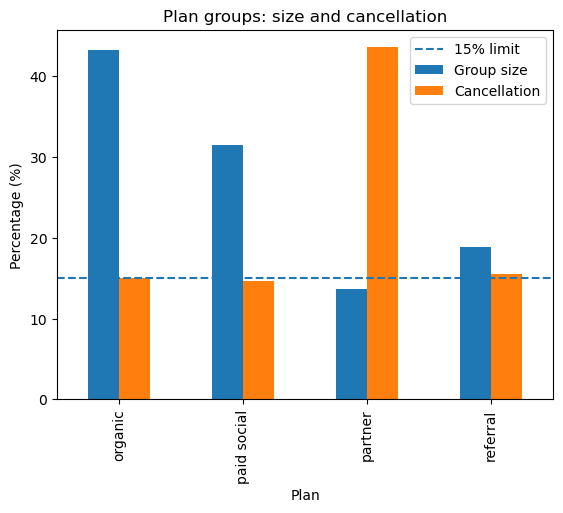

In [16]:
import matplotlib.pyplot as plt

summary[["size_%", "cancel_%"]].plot(kind="bar")

plt.axhline(15, linestyle="--")

plt.title("Plan groups: size and cancellation")
plt.xlabel("Plan")
plt.ylabel("Percentage (%)")
plt.legend(["15% limit", "Group size", "Cancellation"])
plt.show()

### Figure 2 — Country labels before and after cleaning

The country column contained different labels for the same countries.
We cleaned these labels and used one consistent name for each country.

This figure shows the number of unique country labels before and after cleaning.

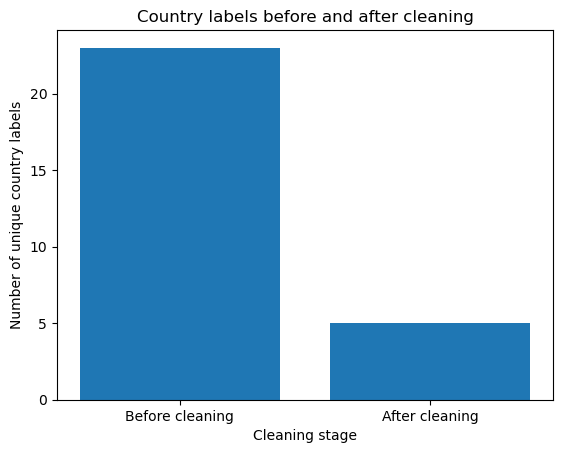

In [17]:
# Load the original customer data
cust_original = pd.read_excel(
    "data_student/customers.xlsx",
    sheet_name="customers"
)
# Count unique country labels before cleaning
before = cust_original["country"].nunique()

# Count unique country labels after cleaning
after = cust["country"].nunique()

# Create Figure 2
plt.bar(
    ["Before cleaning", "After cleaning"],
    [before, after]
)

plt.title("Country labels before and after cleaning")
plt.xlabel("Cleaning stage")
plt.ylabel("Number of unique country labels")

plt.show()

### Figure 3 — March app usage and later cancellation

This figure compares the average number of app sessions in March 2026 for customers who later cancelled and customers who did not cancel.

March usage was known on the pull date, 31 March 2026. The later cancellation data is used only to compare the two groups.

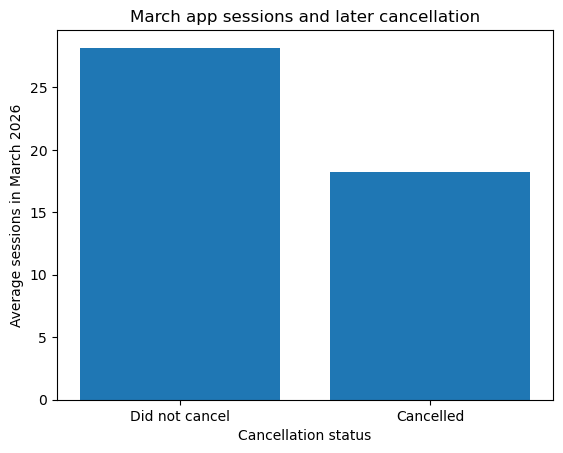

In [18]:
# Keep customers who were subscribed on 31 March
active = subs[subscribed].copy()

# Mark customers who cancelled between 1 April and 29 June
active["cancelled"] = (
    (active["sub_end"] > PULL_DATE) &
    (active["sub_end"] <= END_90)
)

# Get March 2026 app sessions
march = act[act["month"] == "2026-03"][["customer_id", "sessions"]]

# Add March sessions to the active customers
active = active.merge(march, on="customer_id")

# Calculate average March sessions for each cancellation group
usage = active.groupby("cancelled")["sessions"].mean()

# Make Figure 3
plt.bar(
    ["Did not cancel", "Cancelled"],
    [usage[False], usage[True]]
)

plt.title("March app sessions and later cancellation")
plt.xlabel("Cancellation status")
plt.ylabel("Average sessions in March 2026")

plt.show()




### 4.1 Columns we must not use (Q10)

Some columns contain information that is only available after a customer has cancelled.
Therefore, these columns could not have been known on 31 March 2026 and must not be used
to predict cancellation.

The columns are:
- days_until_churn
- cancel_reason
- last_agent_note_after_churn

In [19]:
# Columns that contain information from after cancellation
post_cancel_columns = [
    "days_until_churn",
    "cancel_reason",
    "last_agent_note_after_churn"
]

# Show the columns
print("Columns we must not use:")
for column in post_cancel_columns:
    print(column)

answers["Q10"] = (
    post_cancel_columns,
    "Excluded columns filled after cancellation"
)

Columns we must not use:
days_until_churn
cancel_reason
last_agent_note_after_churn


### 4.2 Shortlist, at most 8 things (Q11)

**Predictors of Cancellation:**
We use information available on 31 March 2026 to identify possible predictors of customer cancellation. These include March 2026 app activity, customer characteristics, subscription tenure, and the self-made measure of minutes per session. Eight predictors are selected and compared to identify factors that may be related to later cancellation.

In [20]:
# Get March 2026 activity
march = act[act["month"] == "2026-03"][[
    "customer_id", "sessions", "active_minutes"
]].copy()

# Create minutes per session
march["minutes_per_session"] = (
    march["active_minutes"] / march["sessions"]
)

# Calculate tenure in days
subs["sub_start"] = pd.to_datetime(subs["sub_start"])
subs["tenure_days"] = (
    PULL_DATE - subs["sub_start"]
).dt.days

# Add customer information
march = march.merge(
    cust[[
        "customer_id",
        "acquisition_channel",
        "plan_tier",
        "country",
        "billing_cycle"
    ]],
    on="customer_id"
)

# Add tenure
march = march.merge(
    subs[["customer_id", "tenure_days"]],
    on="customer_id"
)

# Select the 8 things
eight_things = march[[
    "sessions",
    "active_minutes",
    "minutes_per_session",
    "tenure_days",
    "acquisition_channel",
    "plan_tier",
    "country",
    "billing_cycle"
]]

# Show 10 rows
eight_things.head(10)

,sessions,active_minutes,minutes_per_session,tenure_days,acquisition_channel,plan_tier,country,billing_cycle
0,19,233,12.263158,74,organic,plus,Germany,monthly
1,63,379,6.015873,252,organic,plus,Denmark,annual
2,12,29,2.416667,317,organic,basic,Germany,monthly
3,37,769,20.783784,158,referral,basic,Denmark,monthly
4,39,101,2.589744,160,paid social,pro,Sweden,annual
5,32,194,6.062500,305,paid social,plus,Norway,monthly
6,39,117,3.000000,267,paid social,basic,Sweden,monthly
7,6,51,8.500000,37,paid social,pro,Sweden,annual
8,41,1919,46.804878,5,paid social,basic,Sweden,annual
9,5,41,8.200000,163,partner,pro,Finland,monthly


**Key Predictors of Cancellation:**
The analysis focuses on three main predictors: sessions, minutes per session, and acquisition channel. These were selected from the eight available predictors as the factors considered most useful for understanding later customer cancellation.


In [21]:
top_3 = [
    "sessions",
    "minutes_per_session",
    "acquisition_channel"
]

print("The three most important things for cancellation are:", top_3)

answers["Q11"] = (
    top_3,
    "Selected the three most important things"
)

The three most important things for cancellation are: ['sessions', 'minutes_per_session', 'acquisition_channel']


**Email vs dictionary **(Q12)**



In [22]:
answers["Q12"] = (
    "The email said to ignore currency and treat all amounts as EUR",
    "We followed the data dictionary and used currency/FX rates"
)

## Final Answer Table
The table below displays the answers to Q1–Q12 and explains how each answer was calculated.


In [23]:
pd.set_option("display.max_colwidth", None)

pd.DataFrame(
    [(q, a, how) for q, (a, how) in answers.items()],
    columns=["question_id", "answer", "how_we_got_it"]
)

,question_id,answer,how_we_got_it
0,Q1,10818,Counted rows fromtransactions.csv as delivered
1,Q2,10528,Removed duplicate txn_id and kept the newest record
2,Q3,1291,Amounts 100 times the normal amount were divided by 100
3,Q4,Used customer's country to determine local currency,Blank currency was treated as the customer's local currency
4,Q5,1124,Started on or before 31 March 2026 and had not cancelled by that date
5,Q6,17.882562,Percentage of Q5 customers who cancelled between 1 April and 29 June 2026
6,Q7,acquisition_channel=partner,Selected the qualifying group
7,Q8,13.7,Calculated the group size as a percentage of Q5
8,Q9,43.51,Calculated the group's cancellation percentage
9,Q10,"[days_until_churn, cancel_reason, last_agent_note_after_churn]",Excluded columns filled after cancellation


## Memo

### What we recommend
Call everyone who was subscribed on 31 March 2026 and came through the **partner acquisition channel**.

### Why
The partner group represents **13.7%** of the customers who were subscribed on 31 March, so it is within the 15% limit for the call team. At the same time, **43.51%** of customers in this group cancelled between 1 April and 29 June. This is substantially higher than the overall cancellation rate of **17.88%**, suggesting that this group is worth contacting. The group is also clearly defined using information that was available on the pull date.

### What we are unsure about
One real data problem was that some transaction amounts were 100 times too large because they were stored in cents or øre. We corrected these amounts by dividing them by 100. There was also a disagreement between the email and the data dictionary about currency. The email said to treat all amounts as EUR, but we followed the data dictionary and used the currency and FX rates to convert amounts to EUR.